<a href="https://colab.research.google.com/github/samuelorozco641/Seminario_Ciencia_Datos/blob/main/KMeans_Guia_SamuelOrozco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seminario de Ciencia de Datos
## Segmentación de Clientes con K-Means

Notebook estructurado con teoría, práctica, preguntas de evaluación y laboratorio guiado.

## Objetivos
- Comprender el aprendizaje no supervisado
- Aplicar K-Means
- Interpretar clusters y centroides
- Analizar resultados desde negocio

In [10]:
# ===============================
# 1. IMPORTAR LIBRERÍAS
# ===============================

#COMPLETAR POR EL ESTUDIANTE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

## Carga de Datos
Cargar el dataset de clientes.

In [3]:
# COMPLETAR
df = pd.read_csv('/content/drive/MyDrive/Seminario Ciencia Datos/Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Selección de Variables
Usar: Annual Income y Spending Score.

In [4]:
# COMPLETAR
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

## Método del Codo

In [5]:
# COMPLETAR
inercia = []
for k in range(1, 11):
    modelo = KMeans(n_clusters=k, random_state=42)
    modelo.fit(X)
    inercia.append(modelo.inertia_)

## Entrenamiento del Modelo

In [6]:
# COMPLETAR
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)
df['Cluster'] = kmeans.labels_

## Visualización

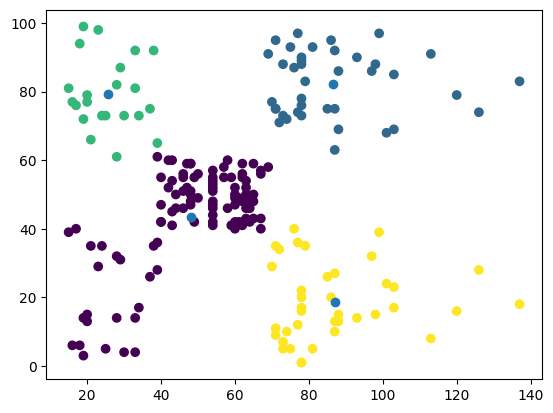

In [8]:
# COMPLETAR VISUALIZACIÓN
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'])
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1])

In [11]:
caracteristicas = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

print("📊 PREPARACIÓN DE DATOS")
print("="*70)
print(f"\nCaracterísticas seleccionadas para clustering:")
for i, feat in enumerate(caracteristicas, 1):
    print(f"  {i}. {feat}")

# Extraer las características
X = df[caracteristicas].copy()

# Normalizar (StandardScaler)
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

print(f"\n✅ Datos escalados correctamente")
print(f"   Forma original: {X.shape}")
print(f"   Forma escalada: {X_escalado.shape}")
print(f"\n   Rango original:")
print(f"   - Age: {X['Age'].min()}-{X['Age'].max()} años")
print(f"   - Annual Income: {X['Annual Income (k$)'].min()}-{X['Annual Income (k$)'].max()} k$")
print(f"   - Spending Score: {X['Spending Score (1-100)'].min()}-{X['Spending Score (1-100)'].max()}")
print(f"\n   Después de escalado (StandardScaler):")
print(f"   - Media: {X_escalado.mean(axis=0).round(4)}")
print(f"   - Desv. Est.: {X_escalado.std(axis=0).round(4)}")

📊 PREPARACIÓN DE DATOS

Características seleccionadas para clustering:
  1. Age
  2. Annual Income (k$)
  3. Spending Score (1-100)

✅ Datos escalados correctamente
   Forma original: (200, 3)
   Forma escalada: (200, 3)

   Rango original:
   - Age: 18-70 años
   - Annual Income: 15-137 k$
   - Spending Score: 1-99

   Después de escalado (StandardScaler):
   - Media: [-0. -0. -0.]
   - Desv. Est.: [1. 1. 1.]


In [12]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []

print("⏳ Evaluando diferentes valores de K...\n")
print("K  | Inercia   | Silhouette | Davies-Bouldin")
print("-" * 50)

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_escalado)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_escalado, kmeans.labels_)
    davies_bouldin = davies_bouldin_score(X_escalado, kmeans.labels_)

    inertias.append(inertia)
    silhouette_scores.append(silhouette)
    davies_bouldin_scores.append(davies_bouldin)

    print(f"{k:2d} | {inertia:9.2f} | {silhouette:10.4f} | {davies_bouldin:14.4f}")

print("\n✅ Evaluación completada")
print("\nInterpretación:")
print("  • Inercia: Menor es mejor (distancia dentro de clusters)")
print("  • Silhouette: Mayor es mejor (-1 a 1)")
print("  • Davies-Bouldin: Menor es mejor")

⏳ Evaluando diferentes valores de K...

K  | Inercia   | Silhouette | Davies-Bouldin
--------------------------------------------------
 2 |    389.39 |     0.3355 |         1.2607
 3 |    295.21 |     0.3578 |         1.0503
 4 |    205.23 |     0.4040 |         0.9308
 5 |    168.25 |     0.4166 |         0.8746
 6 |    133.87 |     0.4284 |         0.8254
 7 |    117.01 |     0.4172 |         0.7935
 8 |    103.87 |     0.4082 |         0.8918
 9 |     93.09 |     0.4177 |         0.8198
10 |     82.39 |     0.4066 |         0.8679

✅ Evaluación completada

Interpretación:
  • Inercia: Menor es mejor (distancia dentro de clusters)
  • Silhouette: Mayor es mejor (-1 a 1)
  • Davies-Bouldin: Menor es mejor


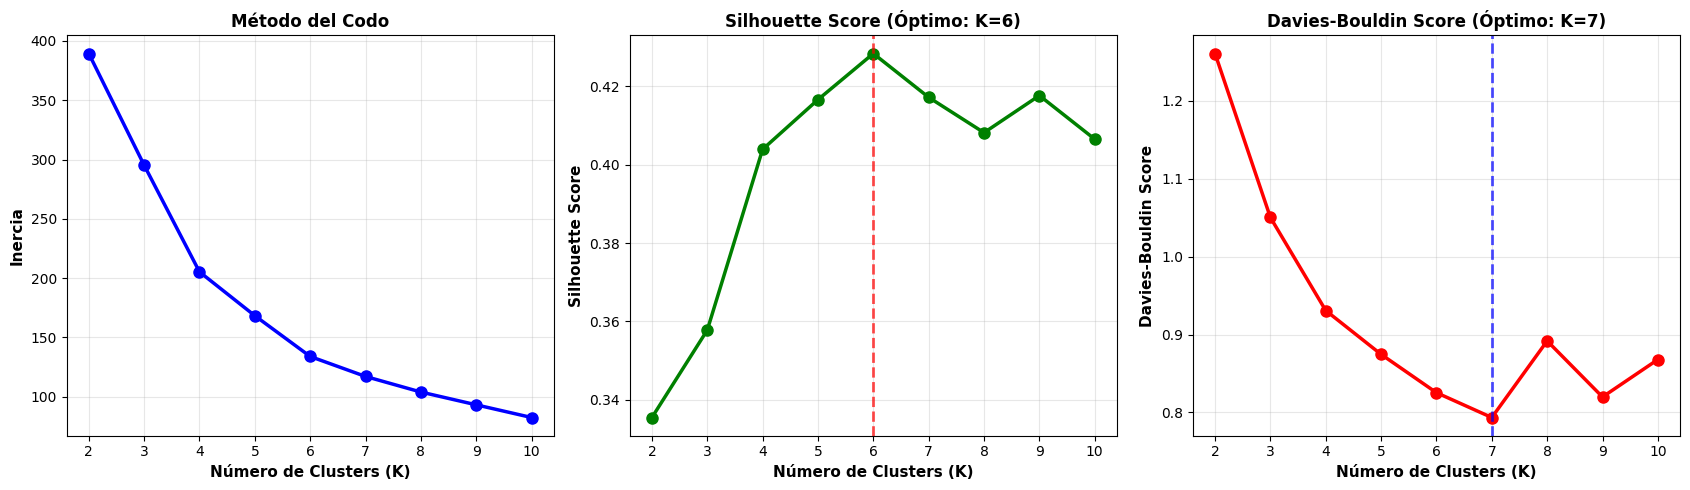


📊 RECOMENDACIÓN:
   K óptimo según Silhouette: 6
   K óptimo según Davies-Bouldin: 7
   K a usar: 6 (consenso de métricas)


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(k_values, inertias, 'bo-', linewidth=2.5, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Inercia', fontweight='bold', fontsize=11)
axes[0].set_title('Método del Codo', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_values, silhouette_scores, 'go-', linewidth=2.5, markersize=8)
max_silhouette_k = k_values[np.argmax(silhouette_scores)]
axes[1].axvline(x=max_silhouette_k, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1].set_xlabel('Número de Clusters (K)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontweight='bold', fontsize=11)
axes[1].set_title(f'Silhouette Score (Óptimo: K={max_silhouette_k})', fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_values, davies_bouldin_scores, 'ro-', linewidth=2.5, markersize=8)
min_db_k = k_values[np.argmin(davies_bouldin_scores)]
axes[2].axvline(x=min_db_k, color='blue', linestyle='--', linewidth=2, alpha=0.7)
axes[2].set_xlabel('Número de Clusters (K)', fontweight='bold', fontsize=11)
axes[2].set_ylabel('Davies-Bouldin Score', fontweight='bold', fontsize=11)
axes[2].set_title(f'Davies-Bouldin Score (Óptimo: K={min_db_k})', fontweight='bold', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 RECOMENDACIÓN:")
print(f"   K óptimo según Silhouette: {max_silhouette_k}")
print(f"   K óptimo según Davies-Bouldin: {min_db_k}")
print(f"   K a usar: {max_silhouette_k} (consenso de métricas)")

In [14]:
display(df)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,2
2,3,Female,20,16,6,0
3,4,Female,23,16,77,2
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


In [15]:
df_sub = df[['Annual Income (k$)','Spending Score (1-100)']]
df_sub

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [16]:
kmeans = KMeans(n_clusters=4, n_init= 10).fit(df_sub.values)
kmeans.labels_

array([3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2], dtype=int32)

In [17]:
df['Cluster'] = kmeans.labels_

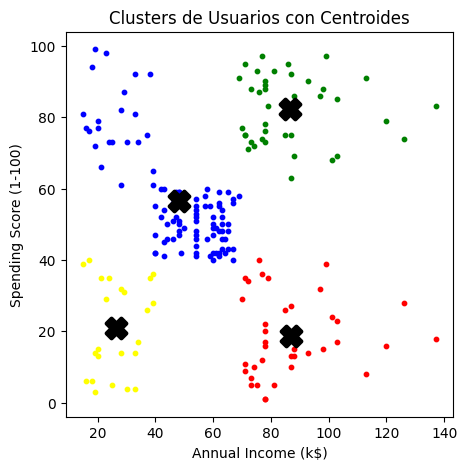

In [18]:
plt.figure(figsize=(5, 5), dpi=100)

colors = ['blue', 'red', 'green', 'yellow']

# Graficar puntos de clusters
for cluster in range(kmeans.n_clusters):
    plt.scatter(
        df[df["Cluster"] == cluster]["Annual Income (k$)"],
        df[df["Cluster"] == cluster]["Spending Score (1-100)"],
        marker='o',
        s=10,
        color=colors[cluster]
    )

# Graficar los centroides
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200,
    linewidths=3,
    color='black',
    label='Centroides'
)

plt.title('Clusters de Usuarios con Centroides')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.show()

In [19]:
print("Clientes con los ingresos anuales más altos:")
df_top_income = df.sort_values(by='Annual Income (k$)', ascending=False)
display(df_top_income)

Clientes con los ingresos anuales más altos:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
199,200,Male,30,137,83,2
198,199,Male,32,137,18,1
197,198,Male,32,126,74,2
196,197,Female,45,126,28,1
195,196,Female,35,120,79,2
...,...,...,...,...,...,...
5,6,Female,22,17,76,0
2,3,Female,20,16,6,3
3,4,Female,23,16,77,0
0,1,Male,19,15,39,3


In [20]:
print("ID de Cliente y su Cluster asignado:")
display(df[['CustomerID', 'Cluster']])

ID de Cliente y su Cluster asignado:


,CustomerID,Cluster
0,1,3
1,2,0
2,3,3
3,4,0
4,5,3
...,...,...
195,196,2
196,197,1
197,198,2
198,199,1


## Preguntas de Evaluación
1. ¿Por qué es aprendizaje no supervisado?
2. ¿Qué es un centroide?
3. ¿Qué sucede si K es muy alto?
4. ¿Para qué sirve el método del codo?
5. Interprete los clusters desde negocio.

## Conclusión
K-Means permite segmentar clientes y apoyar decisiones estratégicas basadas en datos.

# **Respuesta**



1.   **¿Por qué no es aprendizaje no supervisado?:** Esto es porque el algoritmo trabaja con datos que no tienen etiquetas o categorías definidas previamente. El K-Means analiza las características de los clientes y encuentra patrones o grupos similares automáticamente, sin la necesidad de que le señalen a cual cliente pertenece cada grupo.
2.   **¿Qué es un centroide?:** Es el punto central del cluster y representa el promedio de las características de todos los datos que pertenecen a ese grupo.

3. **¿Qué sucede si K es muy alto?:** El modelo crearía muchos grupos pequeños y puede sobreajustar los datos, lo que hace que pierdan su utilidad práctica, ya que la segmentación sería demasiado especifica y dificil de interpretar.

4. **¿Para qué sirve el método del codo?:** Este ayuda a encontrar el número óptimo de clusters.

5. **Interprete los clusters desde negocio:**



* Clientes con altos ingresos y alto gasto: clientes premium o VIP.
* Clientes con altos ingresos y bajo gasto: clientes con potencial de compra.
* Clientes con bajos ingresos y alto gasto: compradores frecuentes sensibles a promociones.
* Clientes con bajos ingresos y bajo gasto: clientes de bajo valor comercial.



